In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [21]:
df1=pd.read_csv("survey.csv")
df2=pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df3=pd.read_csv("user_behavior_dataset.csv")

In [22]:
df1.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,27-08-2014 11:29,37,Female,United States,IL,NaN,No,Yes,Often,Jun-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,27-08-2014 11:29,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,27-08-2014 11:29,32,Male,Canada,NaN,NaN,No,No,Rarely,Jun-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,27-08-2014 11:29,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,27-08-2014 11:30,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [23]:
df2.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [24]:
df3.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [25]:
df1,df2,df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


(             Timestamp  Age  Gender         Country state self_employed  \
 0     27-08-2014 11:29   37  Female   United States    IL           NaN   
 1     27-08-2014 11:29   44       M   United States    IN           NaN   
 2     27-08-2014 11:29   32    Male          Canada   NaN           NaN   
 3     27-08-2014 11:29   31    Male  United Kingdom   NaN           NaN   
 4     27-08-2014 11:30   31    Male   United States    TX           NaN   
 ...                ...  ...     ...             ...   ...           ...   
 1254  12-09-2015 11:17   26    male  United Kingdom   NaN            No   
 1255  26-09-2015 01:07   32    Male   United States    IL            No   
 1256  07-11-2015 12:36   34    male   United States    CA            No   
 1257  30-11-2015 21:25   46       f   United States    NC            No   
 1258  01-02-2016 23:04   25    Male   United States    IL            No   
 
      family_history treatment work_interfere    no_employees  ...  \
 0              

In [26]:
df1.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [27]:
df2.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [28]:
df3.isnull().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

In [29]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [30]:
# Reset index to align rows
df1 = df1.reset_index(drop=True)
df2 = df2.reset_index(drop=True)
df3 = df3.reset_index(drop=True)

# Combine into one dataset
df = pd.concat([df1, df2, df3], axis=1)

print(df.head())

          Timestamp Age  Gender         Country state self_employed  \
0  27-08-2014 11:29  37  Female   United States    IL           NaN   
1  27-08-2014 11:29  44       M   United States    IN           NaN   
2  27-08-2014 11:29  32    Male          Canada   NaN           NaN   
3  27-08-2014 11:29  31    Male  United Kingdom   NaN           NaN   
4  27-08-2014 11:30  31    Male   United States    TX           NaN   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often          Jun-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely          Jun-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

     Device Model Operating System App Usage Time (min/day)  \
0  Google Pixel 5          Android                    393.0   
1       OnePlus 9          Android                

In [31]:
# Remove missing values
df = df.dropna()

# Convert categorical to numeric if needed
# Example:
# df['addiction_level'] = df['addiction_level'].map({'Low':0, 'Medium':1, 'High':2})

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 49 to 373
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   13 non-null     object 
 1   Age                         13 non-null     int64  
 2   Gender                      13 non-null     object 
 3   Country                     13 non-null     object 
 4   state                       13 non-null     object 
 5   self_employed               13 non-null     object 
 6   family_history              13 non-null     object 
 7   treatment                   13 non-null     object 
 8   work_interfere              13 non-null     object 
 9   no_employees                13 non-null     object 
 10  remote_work                 13 non-null     object 
 11  tech_company                13 non-null     object 
 12  benefits                    13 non-null     object 
 13  care_options                13 non-null 

In [42]:
df['Screen On Time (hours/day)'] = pd.to_numeric(df['Screen On Time (hours/day)'], errors='coerce')
df['Sleep Duration'] = pd.to_numeric(df['Sleep Duration'], errors='coerce')
df['Stress Level'] = pd.to_numeric(df['Stress Level'], errors='coerce')

In [43]:
df['treatment'] = df['treatment'].map({'Yes':1, 'No':0})

In [44]:
df = df.dropna()

In [45]:
# New features
df['high_screen_time'] = (df['Screen On Time (hours/day)'] > 6).astype(int)
df['sleep_deficit'] = 8 - df['Sleep Duration']

# Burnout score
df['burnout_score'] = (
    df['Screen On Time (hours/day)'] * 0.4 +
    df['Stress Level'] * 0.4 -
    df['Sleep Duration'] * 0.2 +
    df['treatment'] * 2
)

# Convert to categories
def label_burnout(x):
    if x < 4:
        return 0   # Low
    elif x < 7:
        return 1   # Medium
    else:
        return 2   # High

df['burnout'] = df['burnout_score'].apply(label_burnout)

print(df.head())

            Timestamp Age  Gender        Country state self_employed  \
49   27-08-2014 11:44  30    male  United States    IL            No   
177  27-08-2014 12:50  32  Female  United States    MA            No   
200  27-08-2014 12:57  27  Female  United States    OR            No   
224  27-08-2014 13:15  23    Male  United States    PA            No   
231  27-08-2014 13:23  41    Male  United States    TX            No   

    family_history  treatment work_interfere no_employees  ...  \
49             Yes          1         Rarely       26-100  ...   
177             No          1          Often       Jun-25  ...   
200            Yes          1      Sometimes       26-100  ...   
224             No          0          Never       26-100  ...   
231             No          1         Rarely     500-1000  ...   

    Battery Drain (mAh/day) Number of Apps Installed Data Usage (MB/day)  \
49                   2736.0                     82.0              1997.0   
177               

In [35]:
print(df.columns)

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments', 'Person ID',
       'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')


In [46]:
print(df.dtypes)

Timestamp                      object
Age                             int64
Gender                         object
Country                        object
state                          object
self_employed                  object
family_history                 object
treatment                       int64
work_interfere                 object
no_employees                   object
remote_work                    object
tech_company                   object
benefits                       object
care_options                   object
wellness_program               object
seek_help                      object
anonymity                      object
leave                          object
mental_health_consequence      object
phys_health_consequence        object
coworkers                      object
supervisor                     object
mental_health_interview        object
phys_health_interview          object
mental_vs_physical             object
obs_consequence                object
comments    

In [47]:
df['Sleep Duration'] = df['Sleep Duration'].astype(str).str.extract('(\d+)').astype(float)

In [50]:
X = df[
    [
        'Screen On Time (hours/day)',
        'Sleep Duration',
        'Stress Level',
        'treatment',
        'high_screen_time',
        'sleep_deficit'
    ]
]

y = df['burnout']

In [51]:
print(df.columns)

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments', 'Person ID',
       'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class',
       'high_screen_time', 'sleep_defic

In [52]:
df['Screen On Time (hours/day)'] = pd.to_numeric(df['Screen On Time (hours/day)'], errors='coerce')
df['Sleep Duration'] = pd.to_numeric(df['Sleep Duration'], errors='coerce')
df['Stress Level'] = pd.to_numeric(df['Stress Level'], errors='coerce')

In [53]:
df['treatment'] = df['treatment'].map({'Yes':1, 'No':0})

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [55]:
pred = model.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.3333333333333333


In [58]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.33      0.50         3
           2       0.00      0.00      0.00         0

    accuracy                           0.33         3
   macro avg       0.33      0.11      0.17         3
weighted avg       1.00      0.33      0.50         3



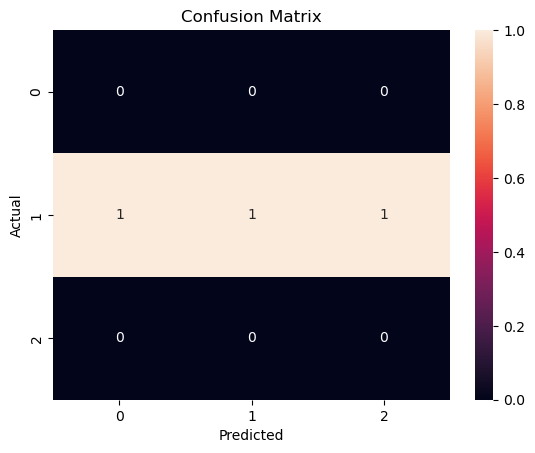

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

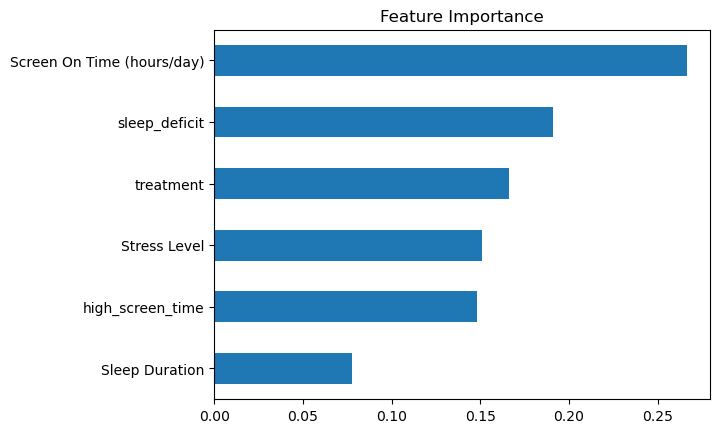

In [60]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [61]:
def suggest(row):
    if row['Screen On Time (hours/day)'] > 7:
        return "Reduce screen time"
    elif row['Sleep Duration'] < 6:
        return "Improve sleep"
    elif row['Stress Level'] > 7:
        return "Manage stress (exercise/meditation)"
    elif row['treatment'] == 1:
        return "Consider professional support"
    else:
        return "Healthy lifestyle"

df['recommendation'] = df.apply(suggest, axis=1)

print(df[['burnout', 'recommendation']].head())

     burnout      recommendation
49         1  Reduce screen time
177        1   Healthy lifestyle
200        2  Reduce screen time
224        0   Healthy lifestyle
231        2  Reduce screen time


In [62]:
sample = [[8, 5, 8, 1, 1, 3]]  # same order as X

prediction = model.predict(sample)

print("Predicted Burnout Level:", prediction)

Predicted Burnout Level: [2]


In [63]:
import pickle

# save model
with open("burnout_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully ✅")

Model saved successfully ✅
